# STEP 4: VAR MODEL — Vector Autoregression
## Multivariate Time Series Forecasting

**Outputs:**
- Lag order selection (AIC/BIC/FPE/HQIC)
- VAR model estimation
- Stability check (eigenvalue test)
- Residual diagnostics (Portmanteau, Normality, Heteroskedasticity)
- Impulse Response Functions (IRF)
- Forecast Error Variance Decomposition (FEVD)
- Out-of-sample forecast with confidence intervals

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.stats.stattools import durbin_watson
from scipy import stats
import warnings
import os

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

SCRIPT_DIR = os.path.dirname(os.path.abspath('step4_var_analysis.ipynb'))
DATA_DIR = os.path.join(SCRIPT_DIR, 'data', 'processed')
OUTPUT_DIR = os.path.join(SCRIPT_DIR, 'outputs', 'step4')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Data Dir   : {DATA_DIR}")
print(f"Output Dir : {OUTPUT_DIR}")

Data Dir   : d:\Nam4-HK1\KLTN\Vietnam_economic_lakehouse\model_test\data\processed
Output Dir : d:\Nam4-HK1\KLTN\Vietnam_economic_lakehouse\model_test\outputs\step4


## 1. Load & Prepare Data

In [2]:
df = pd.read_csv(os.path.join(DATA_DIR, 'step1_cleaned_data.csv'))
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f"Shape      : {df.shape}")
print(f"Date range : {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Columns    : {df.columns.tolist()}")

Shape      : (360, 32)
Date range : 1995-01-01 → 2024-12-01
Columns    : ['date', 'cpi_mom_cpi', 'cpi_mom_inflation', 'core_inflation_rate', 'interest_rate', 'ppi_qoq', 'm2', 'broad_money', 'policy_rate', 'brent', 'wti', 'gasoline_world', 'natural_gas', 'gold', 'silver', 'VNINDEX', 'VN30', 'HNX', 'UPCOM', 'NASDAQ', 'S&P500', 'DAX', 'DOWJONES', 'NIKKEI225', 'HANGSENG', 'USDVND', 'year', 'month', 'quarter', 'shock_2020-03', 'shock_2022-02', 'shock_2023-03']


## 2. Fix Data Quality & Select VAR Variables

In [3]:
# Fix m2=0 issue (recent missing data)
df = df[df['m2'] > 0].reset_index(drop=True)
print(f"After removing m2=0 rows: {len(df)} obs")

# Select key variables: few, representative, interpretable
selected_vars = [
    'core_inflation_rate',  # I(0) - inflation target
    'm2',                   # I(1) - monetary
    'gasoline_world_last',  # I(1) - commodity/energy
    'USDVND_last',          # I(1) - forex
    'cpi_mom'               # I(0) - inflation dynamics
]

selected_vars = [v for v in selected_vars if v in df.columns]

print(f"\nSelected variables ({len(selected_vars)}): {selected_vars}")
print(f"Usable observations: {len(data_raw)}")

data_raw = df.set_index('date')[selected_vars].dropna()

After removing m2=0 rows: 360 obs

Selected variables (2): ['core_inflation_rate', 'm2']


NameError: name 'data_raw' is not defined

In [ ]:
def adf_test(series, name):
    result = adfuller(series, autolag='AIC')
    return {
        'Variable'  : name,
        'ADF_stat'  : round(result[0], 4),
        'p_value'   : round(result[1], 4),
        'Stationary': 'Yes' if result[1] < 0.05 else 'No'
    }

print("\n" + "="*80)
print("STATIONARITY CHECK & TRANSFORMATION")
print("="*80)
print("\nADF Test on levels:")
level_results = pd.DataFrame([adf_test(data_raw[c], c) for c in selected_vars])
print(level_results.to_string(index=False))

# Separate I(0) and I(1) variables
stationary_vars = level_results[level_results['Stationary'] == 'Yes']['Variable'].tolist()
non_stationary_vars = level_results[level_results['Stationary'] == 'No']['Variable'].tolist()

print(f"\n✓ Stationary variables (I(0)): {stationary_vars}")
print(f"✓ Non-stationary variables (I(1)): {non_stationary_vars}")

# Prepare data: keep I(0) in level, difference I(1) with log transform
var_data = data_raw.copy()

if non_stationary_vars:
    print(f"\nTransforming I(1) variables (log + diff):")
    for col in non_stationary_vars:
        # For I(1): use log differences (log_diff)

        if (var_data[col] > 0).all():print(f"\n✓ Final dataset: {var_data.shape[0]} obs × {var_data.shape[1]} vars")

            var_data[col] = np.log(var_data[col]).diff()

            print(f"  {col}: log_diff")print(final_adf.to_string(index=False))

        else:final_adf = pd.DataFrame([adf_test(var_data[c], c) for c in selected_vars])

            var_data[col] = var_data[col].diff()print(f"\nADF Test after transformation (should all be I(0)):")

            print(f"  {col}: diff")

var_data = var_data.dropna()

ADF Test on levels:
          Variable  ADF_stat  p_value Stationary
           cpi_mom   -6.2251   0.0000        Yes
                m2   -1.4683   0.5491         No
      VNINDEX_last   -0.5615   0.8795         No
interest_rate_last   -1.8526   0.3547         No
       USDVND_last    0.4862   0.9844         No

First-differencing: ['m2', 'VNINDEX_last', 'interest_rate_last', 'USDVND_last']

ADF Test after differencing:
          Variable  ADF_stat  p_value Stationary
           cpi_mom   -6.1715      0.0        Yes
                m2   -9.6666      0.0        Yes
      VNINDEX_last   -8.9029      0.0        Yes
interest_rate_last   -9.8662      0.0        Yes
       USDVND_last   -6.9856      0.0        Yes

Final dataset shape: (94, 5)


## 3. Lag Order Selection (Automatic)

In [ ]:
print("\n" + "="*80)
print("LAG ORDER SELECTION")
print("="*80)

model = VAR(var_data)
maxlags = min(12, len(var_data) // 5)  # Rule of thumb: maxlags = n/5
lag_order_results = model.select_order(maxlags=maxlags)

print(f"\nLag selection criteria (maxlags={maxlags}):")

print(lag_order_results.summary())print(f"  FPE: {lag_order_results.fpe}")

print(f"  BIC: {lag_order_results.bic}")

# Use AIC (balances fit and parsimony)print(f"  AIC: {lag_order_results.aic}")

optimal_lag = int(lag_order_results.aic)print(f"\n✓ Selected lag (AIC): p = {optimal_lag}")

optimal_lag = max(1, min(optimal_lag, maxlags))

Lag Order Selection Criteria:
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        46.79      46.94*  2.092e+20*      46.85*
1        46.95       47.83   2.463e+20       47.31
2        47.20       48.82   3.182e+20       47.85
3        47.44       49.78   4.094e+20       48.38
4        47.45       50.53   4.295e+20       48.69
5        47.71       51.53   5.881e+20       49.24
6        47.73       52.28   6.522e+20       49.56
7        48.08       53.36   1.049e+21       50.20
8        47.83       53.84   9.650e+20       50.24
9        47.88       54.64   1.301e+21       50.60
10       47.87       55.35   1.779e+21       50.87
11       46.94       55.16   1.107e+21       50.24
12      46.63*       55.58   1.531e+21       50.22
--------------------------------------------------

Selected lag (AIC, capped at 6): p = 6


## 4. Fit VAR Model with Selected Lag

In [ ]:
print("\n" + "="*80)
print(f"FITTING VAR({optimal_lag})")

print("="*80)print(var_model.summary())

var_model = model.fit(optimal_lag)

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 17, May, 2026
Time:                     19:34:24
--------------------------------------------------------------------
No. of Equations:         5.00000    BIC:                    51.6989
Nobs:                     88.0000    HQIC:                   49.0933
Log likelihood:          -2552.09    FPE:                4.22627e+20
AIC:                      47.3354    Det(Omega_mle):     9.34623e+19
--------------------------------------------------------------------
Results for equation cpi_mom
                           coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------------------
const                       134.918605        32.958369            4.094           0.000
L1.cpi_mom                    0.326260         0.131533            2.480           0.013
L1.m2                     

## 5. Stability Check

VAR Stability: UNSTABLE
All eigenvalue moduli < 1: False
Max modulus: 6.0287


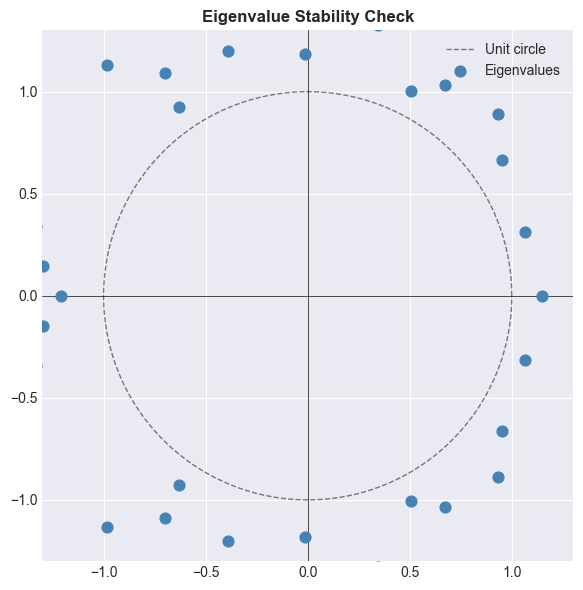

In [ ]:
roots = var_model.roots
moduli = np.abs(roots)
is_stable = all(moduli < 1)

print(f"VAR Stability: {'STABLE' if is_stable else 'UNSTABLE'}")
print(f"All eigenvalue moduli < 1: {is_stable}")
print(f"Max modulus: {moduli.max():.4f}")

fig, ax = plt.subplots(figsize=(6, 6))
theta = np.linspace(0, 2 * np.pi, 300)
ax.plot(np.cos(theta), np.sin(theta), 'k--', linewidth=1, alpha=0.5, label='Unit circle')
ax.scatter(roots.real, roots.imag, color='steelblue', s=60, zorder=5, label='Eigenvalues')
ax.axhline(0, color='k', linewidth=0.5)
ax.axvline(0, color='k', linewidth=0.5)
ax.set_xlim(-1.3, 1.3)
ax.set_ylim(-1.3, 1.3)
ax.set_aspect('equal')
ax.set_title('Eigenvalue Stability Check', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'stability_check.png'), dpi=150)
plt.show()

## 6. Residual Diagnostics

In [ ]:
residuals = var_model.resid

print("Durbin-Watson (serial correlation check, ~2 = no autocorrelation):")
dw_results = []
for col in residuals.columns:
    dw = durbin_watson(residuals[col])
    dw_results.append({'Variable': col, 'DW_Statistic': round(dw, 4)})
print(pd.DataFrame(dw_results).to_string(index=False))

print("\nPortmanteau Test (H0: No autocorrelation in residuals):")
portmanteau = var_model.test_whiteness(nlags=10)
print(portmanteau.summary())

print("\nNormality Test (H0: Residuals are normally distributed):")
normality = var_model.test_normality()
print(normality.summary())

Durbin-Watson (serial correlation check, ~2 = no autocorrelation):
          Variable  DW_Statistic
           cpi_mom        2.0131
                m2        2.0305
      VNINDEX_last        1.9149
interest_rate_last        1.9003
       USDVND_last        1.8640

Portmanteau Test (H0: No autocorrelation in residuals):
Portmanteau-test for residual autocorrelation. H_0: residual autocorrelation up to lag 10 is zero. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value  df
-----------------------------------------
         118.4          124.3   0.102 100
-----------------------------------------

Normality Test (H0: Residuals are normally distributed):
normality (skew and kurtosis) test. H_0: data generated by normally-distributed process. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value df
----------------------------------------
         5632.          18.31   0.000 10
-----------------------------------

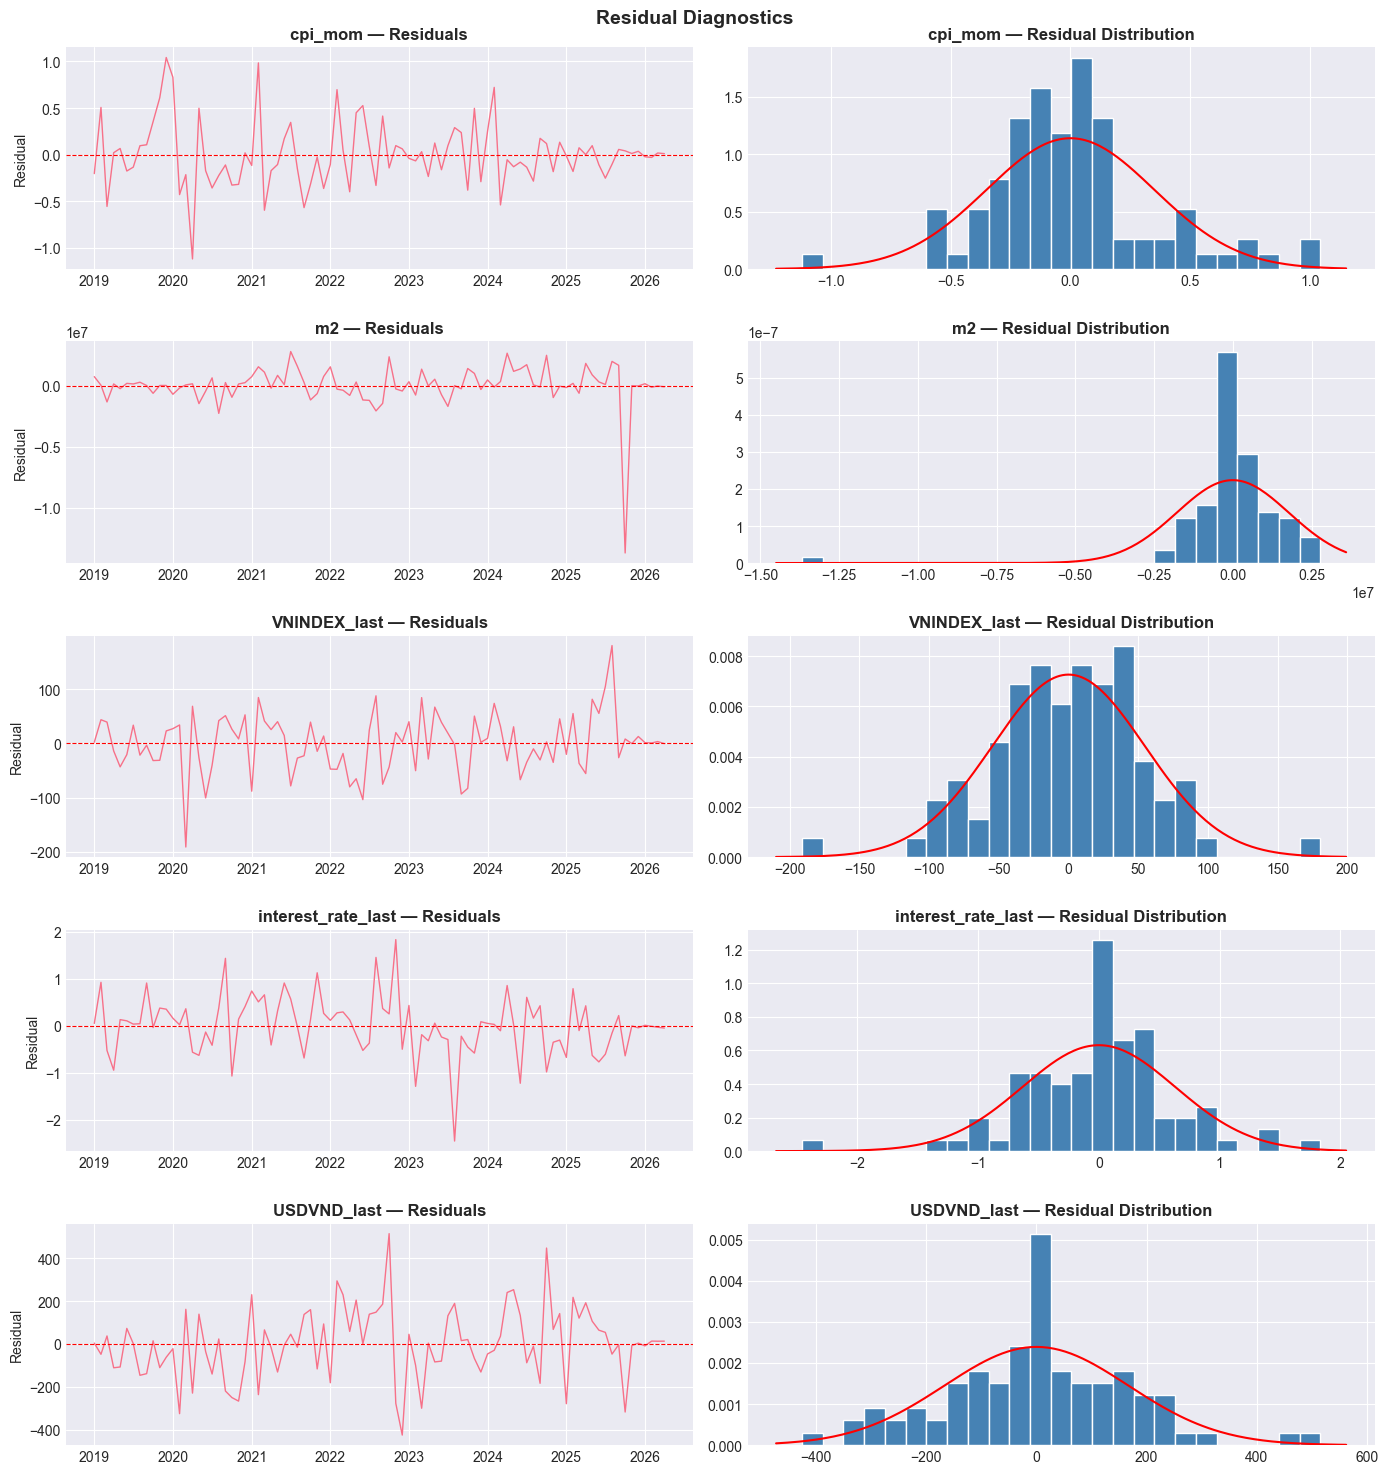

In [ ]:
n_vars = len(selected_vars)
fig, axes = plt.subplots(n_vars, 2, figsize=(14, 3 * n_vars))
fig.suptitle('Residual Diagnostics', fontsize=14, fontweight='bold')

for i, col in enumerate(residuals.columns):
    axes[i, 0].plot(residuals.index, residuals[col], linewidth=1)
    axes[i, 0].axhline(0, color='r', linestyle='--', linewidth=0.8)
    axes[i, 0].set_title(f'{col} — Residuals', fontweight='bold')
    axes[i, 0].set_ylabel('Residual')

    axes[i, 1].hist(residuals[col], bins=25, edgecolor='white', color='steelblue', density=True)
    xmin, xmax = axes[i, 1].get_xlim()
    x = np.linspace(xmin, xmax, 200)
    mu, sigma = residuals[col].mean(), residuals[col].std()
    axes[i, 1].plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=1.5)
    axes[i, 1].set_title(f'{col} — Residual Distribution', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'residual_diagnostics.png'), dpi=150)
plt.show()

## 7. Granger Causality

In [ ]:
print("Granger Causality Tests (H0: X does NOT Granger-cause Y)")
print("p < 0.05 → reject H0 → X Granger-causes Y\n")

granger_results = []

for cause in selected_vars:
    for effect in selected_vars:
        if cause == effect:
            continue
        try:
            test_data = var_data[[effect, cause]]
            result = grangercausalitytests(test_data, maxlag=optimal_lag, verbose=False)
            p_values = [result[lag][0]['ssr_ftest'][1] for lag in range(1, optimal_lag + 1)]
            min_p = min(p_values)
            best_lag = p_values.index(min_p) + 1
            granger_results.append({
                'Cause'   : cause,
                'Effect'  : effect,
                'Best_Lag': best_lag,
                'p_value' : round(min_p, 4),
                'Causal'  : 'Yes' if min_p < 0.05 else 'No'
            })
        except Exception as e:
            granger_results.append({
                'Cause': cause, 'Effect': effect,
                'Best_Lag': np.nan, 'p_value': np.nan, 'Causal': 'Error'
            })

granger_df = pd.DataFrame(granger_results)
print(granger_df.to_string(index=False))

causal_pairs = granger_df[granger_df['Causal'] == 'Yes']
print(f"\nSignificant causal relationships: {len(causal_pairs)}")

Granger Causality Tests (H0: X does NOT Granger-cause Y)
p < 0.05 → reject H0 → X Granger-causes Y

             Cause             Effect  Best_Lag  p_value Causal
           cpi_mom                 m2         1   0.9089     No
           cpi_mom       VNINDEX_last         1   0.0183    Yes
           cpi_mom interest_rate_last         2   0.6572     No
           cpi_mom        USDVND_last         1   0.3291     No
                m2            cpi_mom         1   0.9577     No
                m2       VNINDEX_last         5   0.2137     No
                m2 interest_rate_last         5   0.0877     No
                m2        USDVND_last         3   0.3897     No
      VNINDEX_last            cpi_mom         1   0.1714     No
      VNINDEX_last                 m2         3   0.0177    Yes
      VNINDEX_last interest_rate_last         2   0.0824     No
      VNINDEX_last        USDVND_last         5   0.1440     No
interest_rate_last            cpi_mom         4   0.3286     No
inte

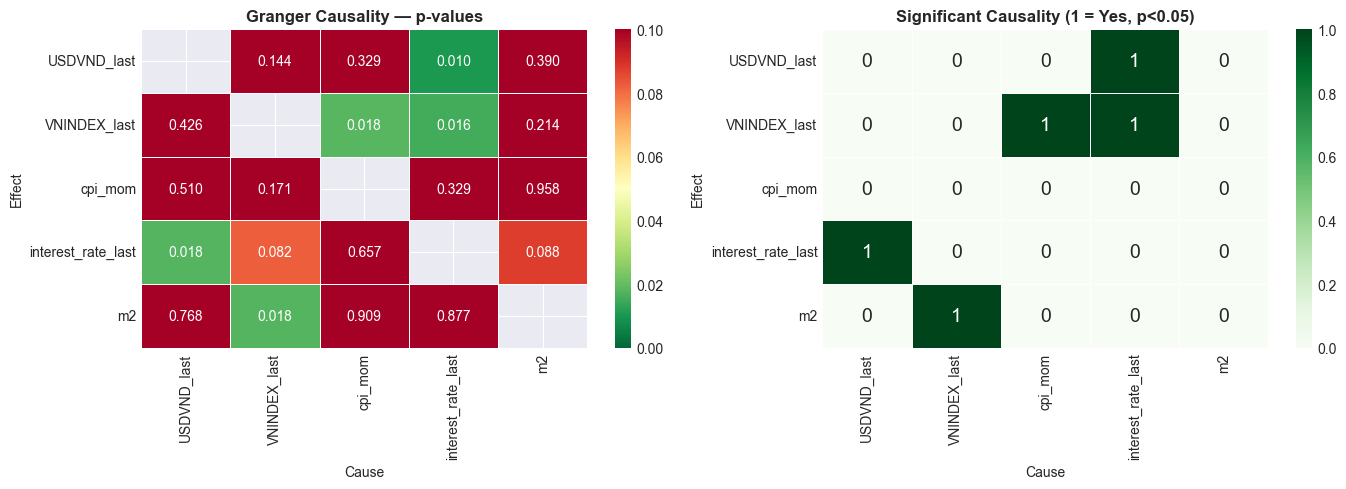

In [ ]:
pivot_p = granger_df.pivot(index='Effect', columns='Cause', values='p_value')
pivot_sig = (pivot_p < 0.05).astype(float)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(pivot_p, annot=True, fmt='.3f', cmap='RdYlGn_r',
            vmin=0, vmax=0.1, ax=axes[0], linewidths=0.5)
axes[0].set_title('Granger Causality — p-values', fontweight='bold')
axes[0].set_xlabel('Cause')
axes[0].set_ylabel('Effect')

sns.heatmap(pivot_sig, annot=True, fmt='.0f', cmap='Greens',
            vmin=0, vmax=1, ax=axes[1], linewidths=0.5,
            annot_kws={'size': 14})
axes[1].set_title('Significant Causality (1 = Yes, p<0.05)', fontweight='bold')
axes[1].set_xlabel('Cause')
axes[1].set_ylabel('Effect')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'granger_causality.png'), dpi=150)
plt.show()

## 8. Impulse Response Functions (IRF)

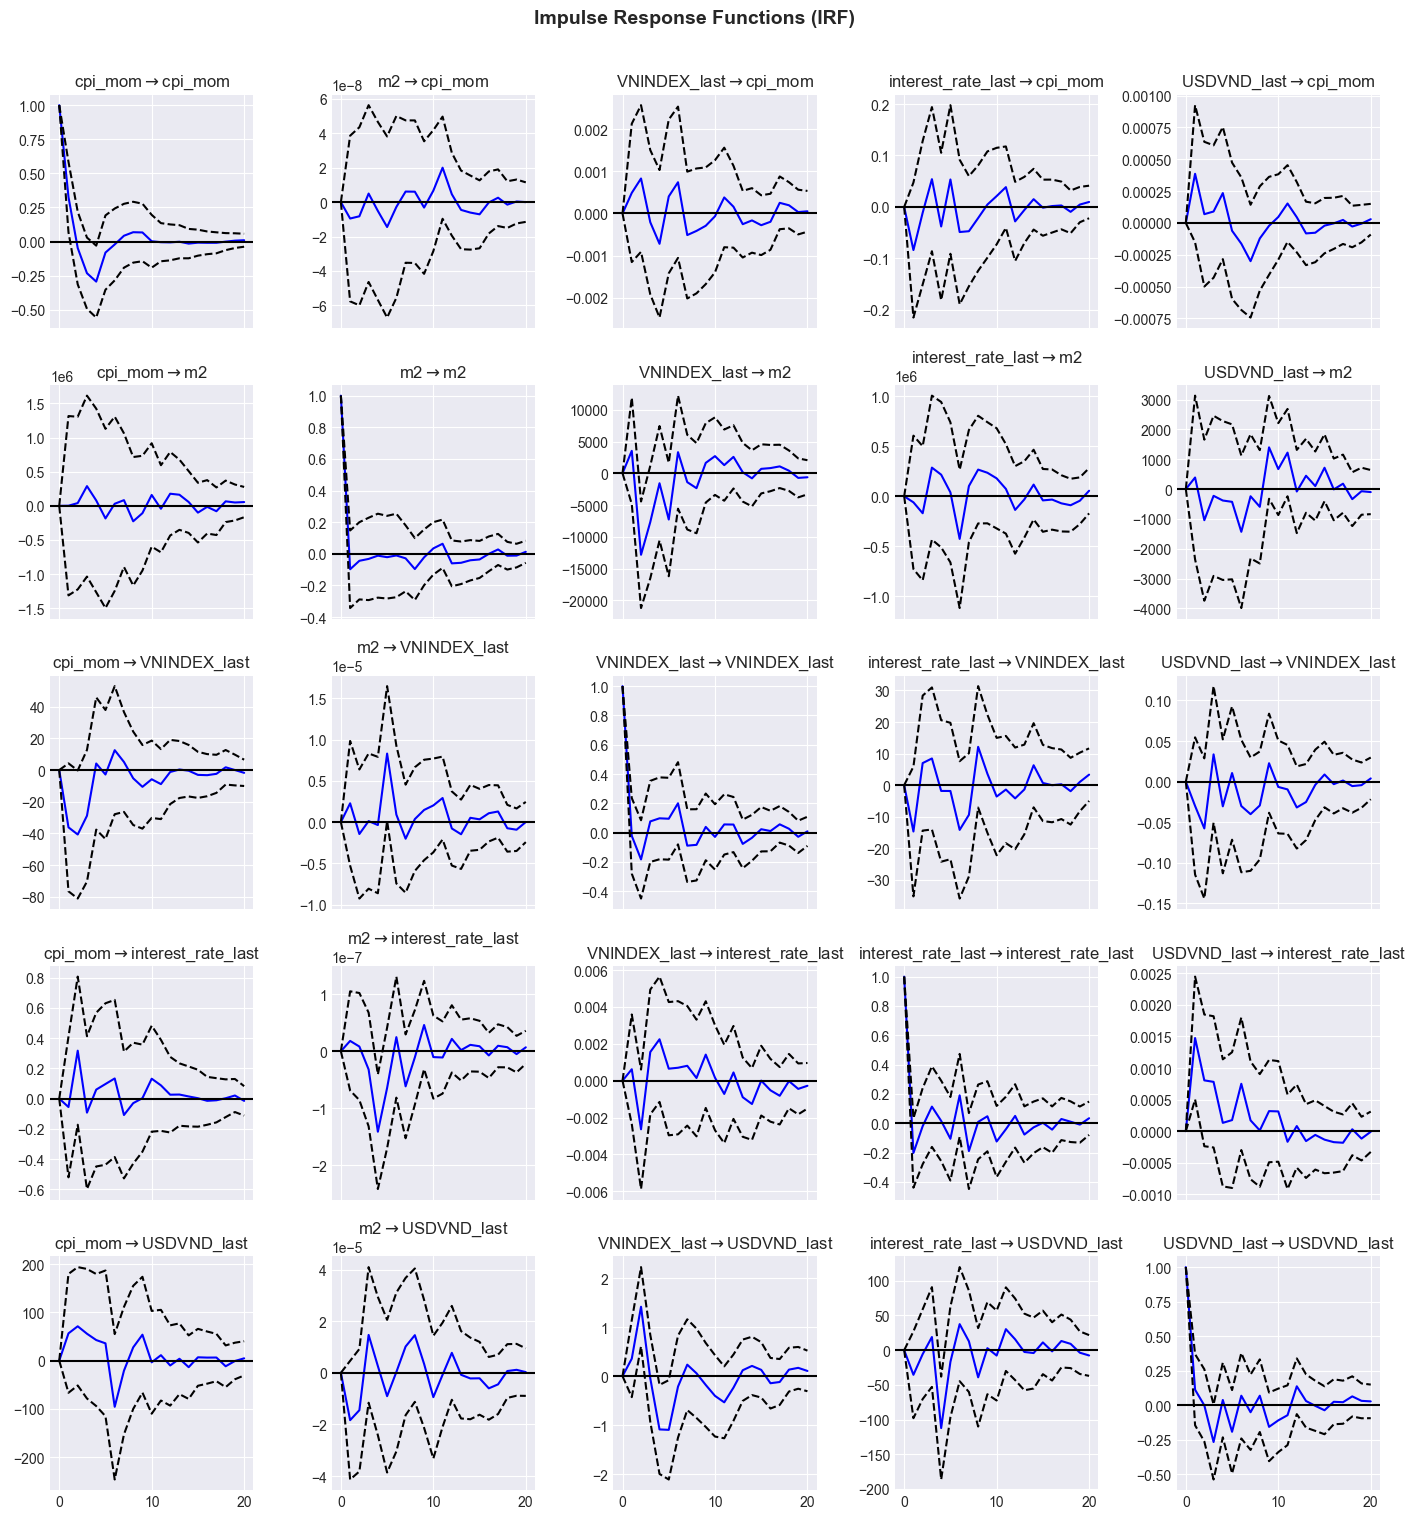

IRF Interpretation:
  - X-axis: months after shock
  - Y-axis: response magnitude
  - Shaded: 95% confidence interval
  - Row = responding variable, Column = shocked variable


In [ ]:
irf = var_model.irf(periods=20)

fig = irf.plot(orth=False, signif=0.05, figsize=(14, 3 * n_vars))
fig.suptitle('Impulse Response Functions (IRF)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'irf.png'), dpi=150, bbox_inches='tight')
plt.show()

print("IRF Interpretation:")
print("  - X-axis: months after shock")
print("  - Y-axis: response magnitude")
print("  - Shaded: 95% confidence interval")
print("  - Row = responding variable, Column = shocked variable")

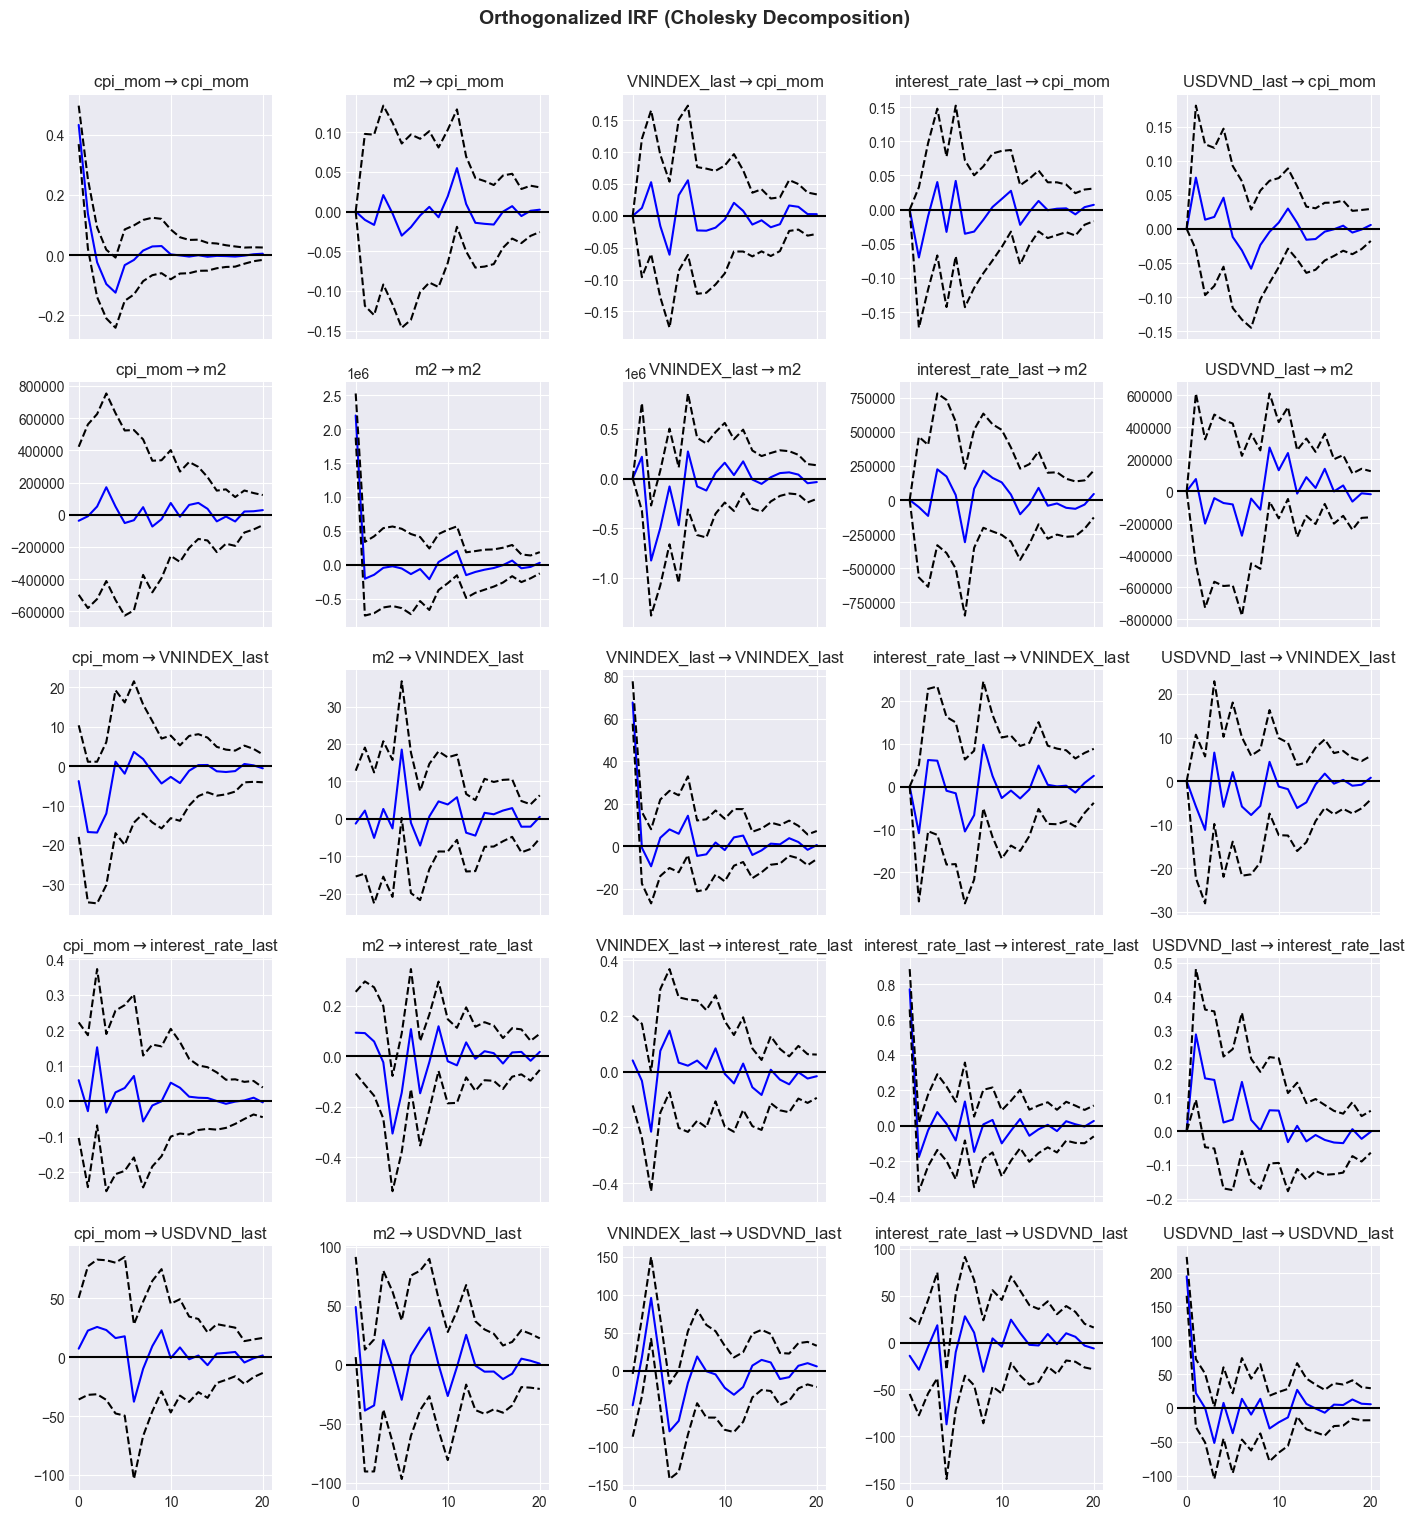

In [ ]:
irf_orth = var_model.irf(periods=20)

fig = irf_orth.plot(orth=True, signif=0.05, figsize=(14, 3 * n_vars))
fig.suptitle('Orthogonalized IRF (Cholesky Decomposition)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'irf_orthogonalized.png'), dpi=150, bbox_inches='tight')
plt.show()

## 9. Forecast Error Variance Decomposition (FEVD)

In [ ]:
fevd = var_model.fevd(periods=20)

print("FEVD at horizon 1, 6, 12, 20 months:")
for h in [1, 6, 12, 20]:
    print(f"\nHorizon {h} months:")
    fevd_df = pd.DataFrame(
        fevd.decomp[:, h-1, :],
        index=selected_vars,
        columns=selected_vars
    ).round(4)
    print(fevd_df.to_string())

FEVD at horizon 1, 6, 12, 20 months:

Horizon 1 months:
                    cpi_mom      m2  VNINDEX_last  interest_rate_last  USDVND_last
cpi_mom              1.0000  0.0000        0.0000              0.0000       0.0000
m2                   0.0003  0.9997        0.0000              0.0000       0.0000
VNINDEX_last         0.0031  0.0004        0.9965              0.0000       0.0000
interest_rate_last   0.0057  0.0145        0.0026              0.9772       0.0000
USDVND_last          0.0012  0.0567        0.0488              0.0047       0.8887

Horizon 6 months:
                    cpi_mom      m2  VNINDEX_last  interest_rate_last  USDVND_last
cpi_mom              0.8940  0.0067        0.0306              0.0364       0.0322
m2                   0.0061  0.7774        0.1914              0.0154       0.0096
VNINDEX_last         0.1149  0.0612        0.7546              0.0311       0.0381
interest_rate_last   0.0298  0.1335        0.0762              0.6308       0.1298
USDVND_last 

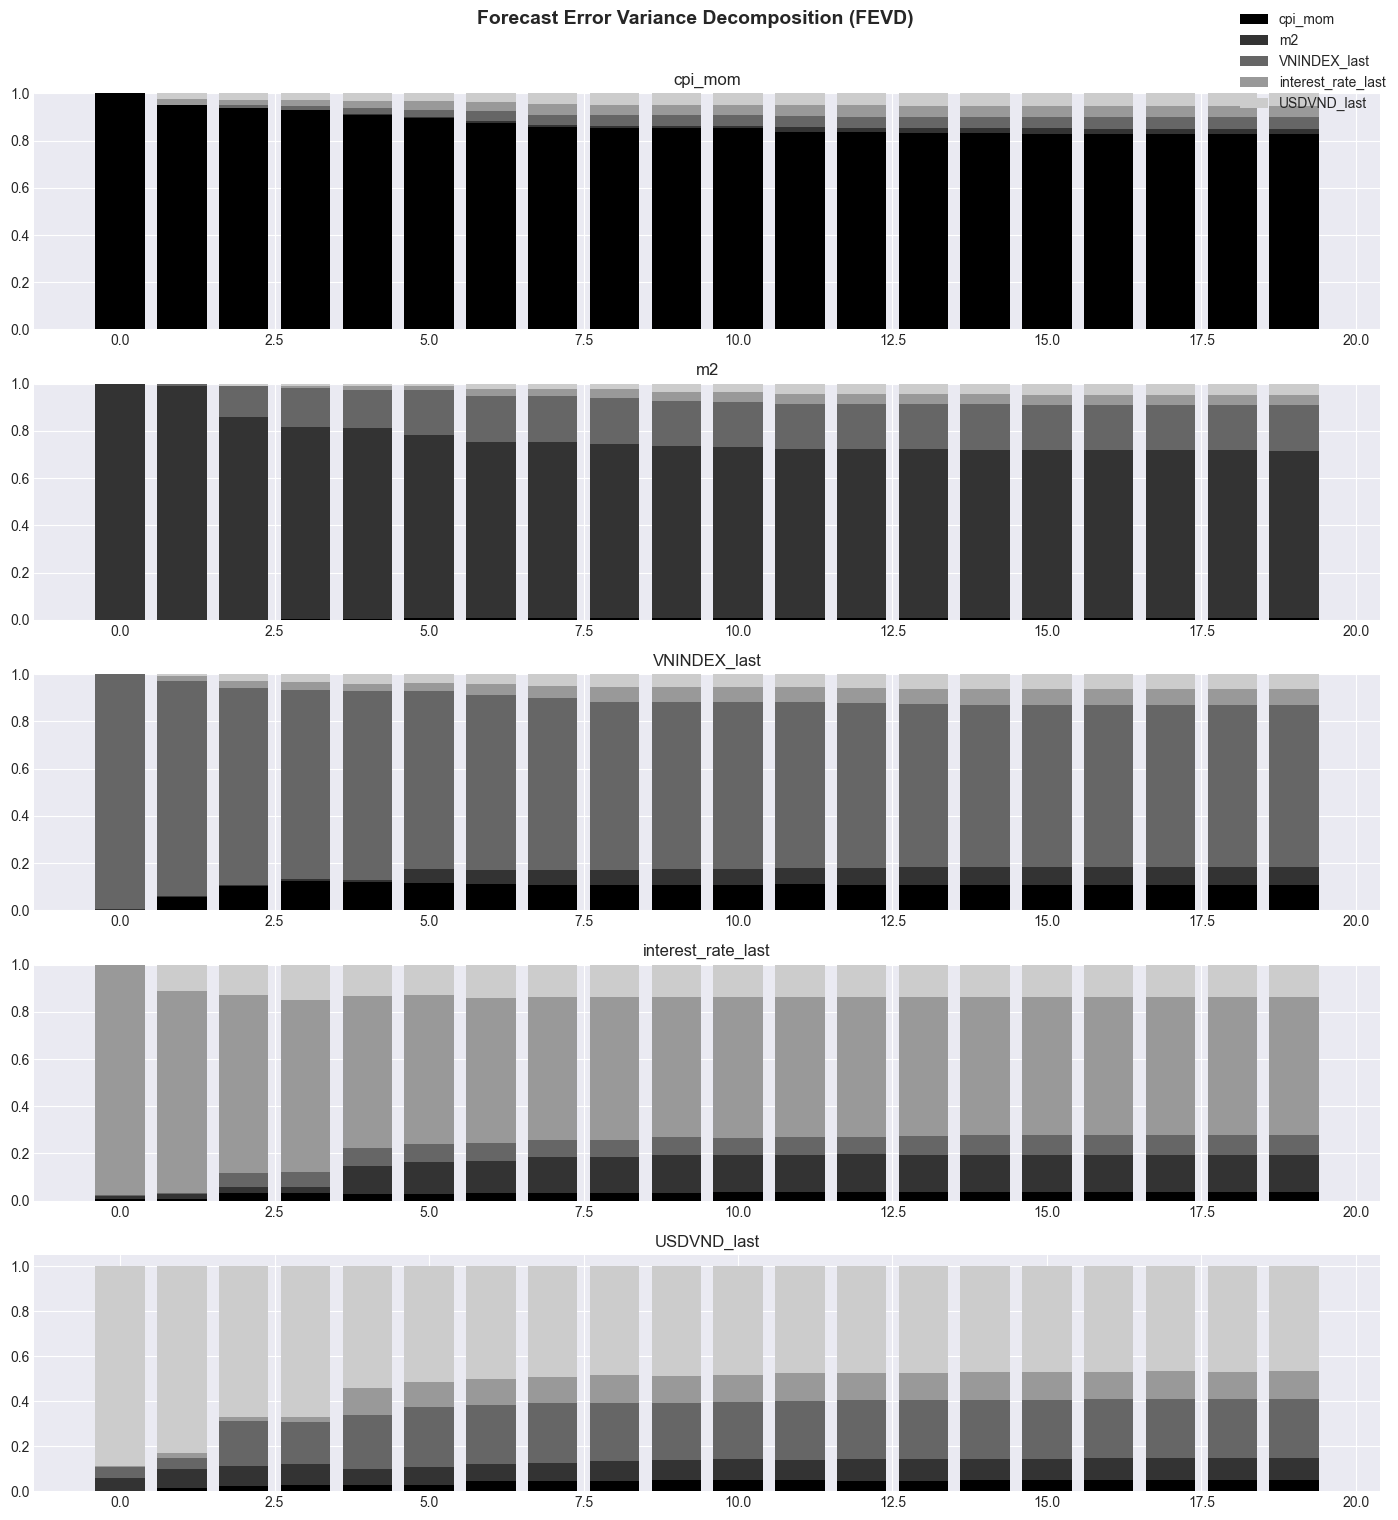

FEVD Interpretation:
  - Shows % of forecast error variance explained by each variable
  - High own-contribution = variable is mostly self-driven
  - High cross-contribution = variable is influenced by others


In [ ]:
fig = fevd.plot(figsize=(14, 3 * n_vars))
fig.suptitle('Forecast Error Variance Decomposition (FEVD)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fevd.png'), dpi=150, bbox_inches='tight')
plt.show()

print("FEVD Interpretation:")
print("  - Shows % of forecast error variance explained by each variable")
print("  - High own-contribution = variable is mostly self-driven")
print("  - High cross-contribution = variable is influenced by others")

## 10. Out-of-Sample Forecast

In [ ]:
FORECAST_STEPS = 12
TRAIN_SIZE = int(len(var_data) * 0.85)

train_data = var_data.iloc[:TRAIN_SIZE]
test_data  = var_data.iloc[TRAIN_SIZE:]

print(f"Train: {len(train_data)} obs | Test: {len(test_data)} obs")

model_train = VAR(train_data)
result_train = model_train.fit(6)

lag_order = result_train.k_ar
forecast_input = train_data.values[-lag_order:]
forecast = result_train.forecast(y=forecast_input, steps=FORECAST_STEPS)
forecast_df = pd.DataFrame(forecast, columns=selected_vars)

forecast_index = var_data.index[TRAIN_SIZE:TRAIN_SIZE + FORECAST_STEPS]
if len(forecast_index) < FORECAST_STEPS:
    last_date = var_data.index[-1]
    freq = pd.infer_freq(var_data.index) or 'MS'
    forecast_index = pd.date_range(start=last_date, periods=FORECAST_STEPS + 1, freq=freq)[1:]

forecast_df.index = forecast_index[:len(forecast_df)]

print(f"\nForecast ({FORECAST_STEPS} steps):")
print(forecast_df.round(4).to_string())

Train: 79 obs | Test: 15 obs

Forecast (12 steps):
             cpi_mom           m2  VNINDEX_last  interest_rate_last  USDVND_last
date                                                                            
2025-02-01  101.1209  209212.5065       -2.7439             -1.9538     175.1079
2025-03-01  100.3853   53104.3996       46.1501             -0.0565     -16.2688
2025-04-01  100.0749  132055.7658      -57.1703             -0.4971     397.2189
2025-05-01  100.0294  -26260.2548      -16.8746             -0.1515     265.5609
2025-06-01  100.3834  196807.4296      -38.7669             -0.2031     550.0723
2025-07-01  100.2497   68743.9161        9.8030              0.7976     -51.7864
2025-08-01  100.6087  184045.3807        6.6536              0.1437     -34.5280
2025-09-01  100.4674  102240.2425        3.3926              0.3702    -108.6966
2025-10-01  100.4067  134652.3267      -60.6420             -0.2809     329.7615
2025-11-01  100.0878   23313.3135        0.8353           

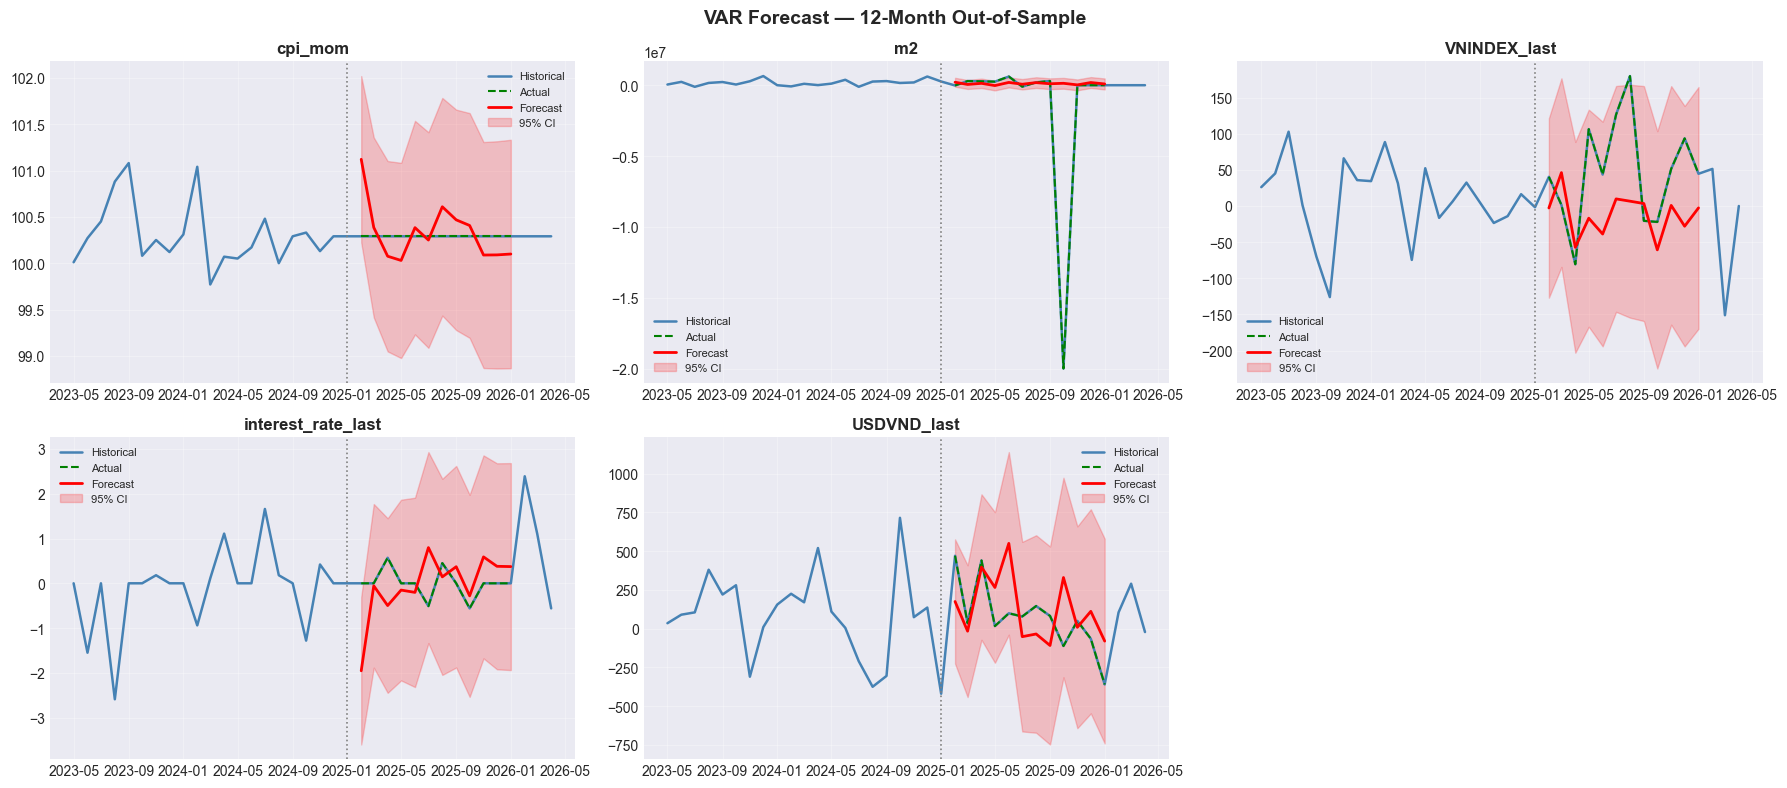

In [ ]:
forecast_ci = result_train.forecast_interval(
    y=forecast_input,
    steps=FORECAST_STEPS,
    alpha=0.05
)
fc_lower = pd.DataFrame(forecast_ci[1], columns=selected_vars, index=forecast_df.index)
fc_upper = pd.DataFrame(forecast_ci[2], columns=selected_vars, index=forecast_df.index)

n_cols = min(n_vars, 3)
n_rows = (n_vars + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
axes = np.array(axes).flatten()

fig.suptitle(f'VAR Forecast — {FORECAST_STEPS}-Month Out-of-Sample', fontsize=14, fontweight='bold')

HISTORY_WINDOW = 36

for i, col in enumerate(selected_vars):
    ax = axes[i]
    history = var_data[col].iloc[-HISTORY_WINDOW:]
    ax.plot(history.index, history.values, color='steelblue', linewidth=1.8, label='Historical')

    if len(test_data) > 0:
        actual = test_data[col].iloc[:FORECAST_STEPS]
        ax.plot(actual.index, actual.values, color='green', linewidth=1.5,
                linestyle='--', label='Actual')

    ax.plot(forecast_df.index, forecast_df[col], color='red',
            linewidth=2, label='Forecast')
    ax.fill_between(forecast_df.index, fc_lower[col], fc_upper[col],
                    alpha=0.2, color='red', label='95% CI')

    ax.axvline(x=train_data.index[-1], color='gray', linestyle=':', linewidth=1.2)
    ax.set_title(col, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'forecast.png'), dpi=150)
plt.show()

## 11. Forecast Evaluation (RMSE, MAE, MAPE)

In [ ]:
def rmse(actual, predicted):
    return np.sqrt(np.mean((actual - predicted) ** 2))

def mae(actual, predicted):
    return np.mean(np.abs(actual - predicted))

def mape(actual, predicted):
    mask = actual != 0
    return np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100

eval_results = []
if len(test_data) > 0:
    for col in selected_vars:
        actual_vals    = test_data[col].values[:FORECAST_STEPS]
        forecast_vals  = forecast_df[col].values[:len(actual_vals)]
        min_len        = min(len(actual_vals), len(forecast_vals))
        actual_vals    = actual_vals[:min_len]
        forecast_vals  = forecast_vals[:min_len]

        eval_results.append({
            'Variable': col,
            'RMSE'    : round(rmse(actual_vals, forecast_vals), 4),
            'MAE'     : round(mae(actual_vals, forecast_vals), 4),
            'MAPE_%'  : round(mape(actual_vals, forecast_vals), 2)
        })

    eval_df = pd.DataFrame(eval_results)
    print("Forecast Evaluation Metrics:")
    print(eval_df.to_string(index=False))
else:
    print("No test data available for evaluation.")

Forecast Evaluation Metrics:
          Variable         RMSE          MAE  MAPE_%
           cpi_mom       0.3012       0.2285    0.23
                m2 5810313.5437 1841521.9895  201.61
      VNINDEX_last      87.3067      73.9865  352.66
interest_rate_last       0.7996       0.5864  140.38
       USDVND_last     249.8575     210.8393  294.41


## 12. Summary

In [ ]:
print("=" * 80)
print("STEP 4 — VAR MODEL SUMMARY")
print("=" * 80)
print(f"Variables      : {selected_vars}")
print(f"Observations   : {len(var_data)}")
print(f"Optimal lag    : p = {optimal_lag}")
print(f"Stable         : {is_stable}")
print(f"Forecast steps : {FORECAST_STEPS} months")
print()

if len(causal_pairs) > 0:
    print("Granger Causal Relationships (p < 0.05):")
    for _, row in causal_pairs.iterrows():
        print(f"  {row['Cause']:20} → {row['Effect']:20} (lag={row['Best_Lag']}, p={row['p_value']})")

print()
print("Outputs saved to:", OUTPUT_DIR)
print("  - stability_check.png")
print("  - residual_diagnostics.png")
print("  - granger_causality.png")
print("  - irf.png")
print("  - irf_orthogonalized.png")
print("  - fevd.png")
print("  - forecast.png")
print()
print("Next: Step 5 — VECM / Cointegration or Deep Learning models")

STEP 4 — VAR MODEL SUMMARY
Variables      : ['cpi_mom', 'm2', 'VNINDEX_last', 'interest_rate_last', 'USDVND_last']
Observations   : 94
Optimal lag    : p = 6
Stable         : False
Forecast steps : 12 months

Granger Causal Relationships (p < 0.05):
  cpi_mom              → VNINDEX_last         (lag=1, p=0.0183)
  VNINDEX_last         → m2                   (lag=3, p=0.0177)
  interest_rate_last   → VNINDEX_last         (lag=1, p=0.0156)
  interest_rate_last   → USDVND_last          (lag=4, p=0.0102)
  USDVND_last          → interest_rate_last   (lag=3, p=0.0178)

Outputs saved to: d:\Nam4-HK1\KLTN\Vietnam_economic_lakehouse\model_test\outputs\step4
  - stability_check.png
  - residual_diagnostics.png
  - granger_causality.png
  - irf.png
  - irf_orthogonalized.png
  - fevd.png
  - forecast.png

Next: Step 5 — VECM / Cointegration or Deep Learning models
